In [3]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

load_dotenv()

model=ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    openai_api_key=os.environ.get("OPENAI_API_KEY")
)

In [4]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str

def create_outline(state:BlogState)->BlogState:
    # fetch title
    title=state['title']

    #Call llm get outline
    prompt=f'Genertae a detailed outline for a blog on the topic -{title}'
    outline=model.invoke(prompt).content

    #update state
    state['outline']=outline

    return state

def create_blog(state:BlogState)->BlogState:
    title=state['title']
    outline=state['outline']

    prompt=f'Write a detailed blog on the title - {title} using the following outline - {outline}'
    content=model.invoke(prompt).content
    state['content']=content

    return state


In [5]:
graph=StateGraph(BlogState)

# nodes

graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)

#Edges

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

workflow=graph.compile()

In [6]:
intial_state={'title':'Youtube'}
final_state=workflow.invoke(intial_state)
print(final_state['content'])

# YouTube: The Digital Playground of the 21st Century

## Introduction

Did you know that YouTube has over 2 billion logged-in monthly users, making it one of the most visited websites globally? Each day, people watch over a billion hours of video on the platform, showcasing how deeply embedded it has become in our daily lives. This blog will explore the multifaceted world of YouTube, covering its fascinating history, cultural impact, features, tips for aspiring creators, challenges it faces, and what the future may hold. YouTube has transformed how we consume media, learn new skills, and engage with one another, making it a cornerstone of modern digital culture.

## Section 1: The History of YouTube

### Founding and Early Days

YouTube was founded in February 2005 by Chad Hurley, Steve Chen, and Jawed Karim. The initial vision behind the platform was to create an easy-to-use video-sharing site where anyone could upload and share videos. The first video, titled "Me at the zoo," was up

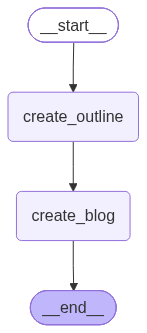

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())